# Benchmarks

Two portfolio benchmarks to compare against our models:
- **1/N portfolio** (buy & hold, no rebalancing)
- **Mean-Variance (MV)** (weekly rebalancing, historical mean/cov)

Additionally, a **random walk forecast baseline** is evaluated on the test set.

---

## Structure
- **Section A:** Full dataset (2022-04-01 → end)
- **Section B:** Test set only (80/20 split, ~Apr 2025 → end)


## Setup & Data Loading

In [1]:
# importing packages
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)
pd.set_option('future.no_silent_downcasting', True)

In [3]:
filepath = 'klines csv data/prices_cleaned'

all_coins = sorted(os.listdir(filepath))

# Preview first coin
glimpse = pd.read_csv(filepath + "/" + all_coins[0])
print(all_coins[0])
print(glimpse.head())
print(f"shape: {glimpse.shape}\n")

# Filter out non-csv files
all_coins = [coin for coin in all_coins if not coin.endswith(".keras")
             and not coin.endswith(".npy") and not coin.endswith(".csv")]

# Merge all data into single dataframe
combined = pd.DataFrame({'time': pd.date_range(start='2022-04-01', periods=len(glimpse), freq='D')})
for coin in all_coins:
    combined[coin] = pd.read_csv(filepath + "/" + coin).sort_values(by='time').close

combined = combined.set_index('time')
print(f"Combined shape: {combined.shape}")
print(f"Coins: {list(combined.columns)}")
print(f"Date range: {combined.index[0].date()} to {combined.index[-1].date()}")

# ── 80/20 train/test split (consistent with CMVO / DCC / XGBoost) ──
total_rows  = len(combined)
test_start  = int(total_rows * 0.8)
test_prices = combined.iloc[test_start:].copy()

print(f"\nTrain rows: {test_start}")
print(f"Test rows:  {len(test_prices)}")
print(f"Test period: {test_prices.index[0].date()} to {test_prices.index[-1].date()}")

all_coins = list(combined.columns)
combined.head()


ADAUSDT
   Unnamed: 0  close    time
0           0  1.165       0
1           1  1.155   86400
2           2  1.186  172800
3           3  1.212  259200
4           4  1.171  345600
shape: (1371, 3)

Combined shape: (1371, 8)
Coins: ['ADAUSDT', 'BCHUSDT', 'BNBUSDT', 'BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'TRXUSDT', 'XRPUSDT']
Date range: 2022-04-01 to 2025-12-31

Train rows: 1096
Test rows:  275
Test period: 2025-04-01 to 2025-12-31


,ADAUSDT,BCHUSDT,BNBUSDT,BTCUSDT,ETHUSDT,SOLUSDT,TRXUSDT,XRPUSDT
time,,,,,,,,
2022-04-01,1.165,377.2,447.7,46283.49,3455.21,134.52,0.07494,0.8277
2022-04-02,1.155,372.5,437.2,45811.00,3443.77,132.49,0.07322,0.8240
2022-04-03,1.186,378.6,450.4,46407.35,3521.91,136.90,0.07312,0.8432
2022-04-04,1.212,376.2,447.6,46580.51,3519.50,132.14,0.07070,0.8260
2022-04-05,1.171,365.4,444.7,45497.55,3406.99,126.87,0.06928,0.8164


## Shared Functions

In [4]:
def eq_weight_returns(prices_df, coins, cost):
    """Buy-and-hold equal weight portfolio — no rebalancing, no transaction costs."""
    n = len(coins)
    prices = prices_df[coins].values

    # Apply transaction cost on initial purchase
    net_value = 1.0 - cost
    holdings = (1.0 / n) * net_value / prices[0]

    portfolio_values = [1.0]
    pct_change = [0.0]

    for i in range(1, len(prices)):
        current_value = (holdings * prices[i]).sum()
        portfolio_values.append(current_value)
        pct_change.append((current_value / portfolio_values[-2]) - 1)

    return pd.DataFrame({
        'date': prices_df.index.values[:len(portfolio_values)],
        'portfolio_values': portfolio_values,
        'pct_change': pct_change
    })


In [5]:
def solve_mvo(mu, cov, risk_aversion=1.0, weight_ub=0.50):
    """Mean-Variance optimiser with mu/cov scaling (matches CMVO solver)."""
    n       = len(mu)
    cov_reg = cov + 1e-8 * np.eye(n)

    mu_scale  = np.abs(mu).mean()
    cov_scale = np.diag(cov_reg).mean()
    scale     = mu_scale / cov_scale if cov_scale > 0 else 1.0
    cov_scaled = cov_reg * scale

    def neg_obj(w):
        return -(w @ mu - (risk_aversion / 2.0) * (w @ cov_scaled @ w))

    res = minimize(
        neg_obj,
        x0          = np.full(n, 1.0 / n),
        method      = 'SLSQP',
        bounds      = [(0.0, weight_ub)] * n,
        constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1.0}],
        options     = {'ftol': 1e-9, 'maxiter': 1_000},
    )
    if res.success:
        w  = np.clip(res.x, 0.0, weight_ub)
        w /= w.sum()
        return w
    return np.full(n, 1.0 / n)


def mv_weight_returns(prices_df, coins, lookback=60, risk_aversion=1.0,
                      cost=0, weight_ub=0.50):
    """
    Mean-Variance portfolio with weekly rebalancing.
    Uses historical mean/cov from a rolling lookback window.
    """
    n      = len(coins)
    cost   = cost if cost else 0.0
    prices = prices_df[coins].values

    if n * weight_ub < 1.0:
        raise ValueError(
            f"weight_ub={weight_ub} with {n} assets: max possible sum = {n * weight_ub:.2f} < 1.0. "
            f"Raise weight_ub to at least {1.0/n:.4f}."
        )

    REBAL_DAYS = 7  # weekly rebalancing

    holdings = (1.0 / n) / prices[0]
    portfolio_values = [1.0]
    pct_change       = [0.0]

    for i in range(1, len(prices)):
        current_value = (holdings * prices[i]).sum()

        if i % REBAL_DAYS == 0:
            start = max(0, i - lookback)
            window_prices  = prices[start:i]
            window_returns = np.diff(window_prices, axis=0) / window_prices[:-1]

            if len(window_returns) >= 2:
                mu  = window_returns.mean(axis=0)
                cov = np.cov(window_returns.T)
                new_weights = solve_mvo(mu, cov, risk_aversion, weight_ub)
            else:
                new_weights = np.full(n, 1.0 / n)

            current_coin_values = holdings * prices[i]
            target_coin_values  = new_weights * current_value
            trade_amounts       = np.abs(current_coin_values - target_coin_values)
            total_tc            = (trade_amounts * cost).sum()

            net_value     = current_value - total_tc
            holdings      = (new_weights * net_value) / prices[i]
            current_value = net_value

        portfolio_values.append(current_value)
        pct_change.append((current_value / portfolio_values[-2]) - 1.0)

    return pd.DataFrame({
        'date': prices_df.index.values[:len(portfolio_values)],
        'portfolio_values': portfolio_values,
        'pct_change': pct_change
    })


In [6]:
def calculate_metrics(result):
    """
    Calculate sharpe, calmar, max drawdown.
    arg:
        result: df of portfolio values & pct change
    returns:
        dictionary: [sharpe, calmar, mdd, total_return, sortino, final_value]
    """
    pct_changes = result['pct_change'][1:]  # skip the initial 0
    portfolio_values = result['portfolio_values']
    periods = len(pct_changes)

    # max drawdown
    cumulative = (1 + pct_changes).cumprod()
    rolling_peak = cumulative.cummax()
    drawdown = (cumulative - rolling_peak) / rolling_peak
    max_drawdown = drawdown.min()

    # Sharpe ratio — note risk-free rate assumption explicitly
    risk_free_daily = 0.0
    excess = pct_changes - risk_free_daily
    mean_excess = excess.mean()
    std = pct_changes.std()
    sharpe = (mean_excess / std) if std != 0 else 0.0

    # calmar
    total_return = (portfolio_values.iloc[-1] / portfolio_values.iloc[0]) - 1
    calmar = total_return / abs(max_drawdown) if max_drawdown != 0 else 0.0

    # final value
    final_value = portfolio_values.iloc[-1]

    # Sortino
    downside = pct_changes[pct_changes < 0]
    down_std = downside.std()
    sortino = (pct_changes.mean() / down_std) if down_std != 0 else 0.0

    return {
        'mdd': max_drawdown,
        'sharpe': sharpe,
        'calmar': calmar,
        'total_return': total_return,
        'sortino': sortino,
        'final_value': final_value
    }

In [7]:
# save 1/N benchmark performance metrics

file_path = 'Results/1 over n performance metrics.npy'

folder_path = os.path.dirname(file_path)

if not os.path.exists(folder_path):
    os.makedirs(folder_path, exist_ok=True)
    print(f"Created new folders: {folder_path}")

---
## Section A: Full Dataset

Running 1/N and MV benchmarks on the entire dataset (2022-04-01 → end).


### A1. 1/N Portfolio (Buy & Hold)

In [8]:
# 1/N on full dataset
results_1n_full = eq_weight_returns(combined, all_coins, cost=0)
metrics_1n_full = calculate_metrics(results_1n_full)

# Save
np.save(file_path, metrics_1n_full)
print(f'Saved: {file_path}')
results_1n_full.to_csv(
    os.path.join('Results/', '1n_benchmark_full.csv'),
    index=False
)

print('\n=== 1/N Portfolio Metrics (Full Dataset, Buy & Hold) ===')
for metric, value in metrics_1n_full.items():
    print(f'  {metric:>12}: {value:.4f}')


Saved: /content/drive/MyDrive/klines csv/performance_metrics/1 over n performance metrics.npy

=== 1/N Portfolio Metrics (Full Dataset, Buy & Hold) ===
           mdd: -0.6377
        sharpe: 0.0277
        calmar: 1.0798
  total_return: 0.6886
       sortino: 0.0368
   final_value: 1.6886


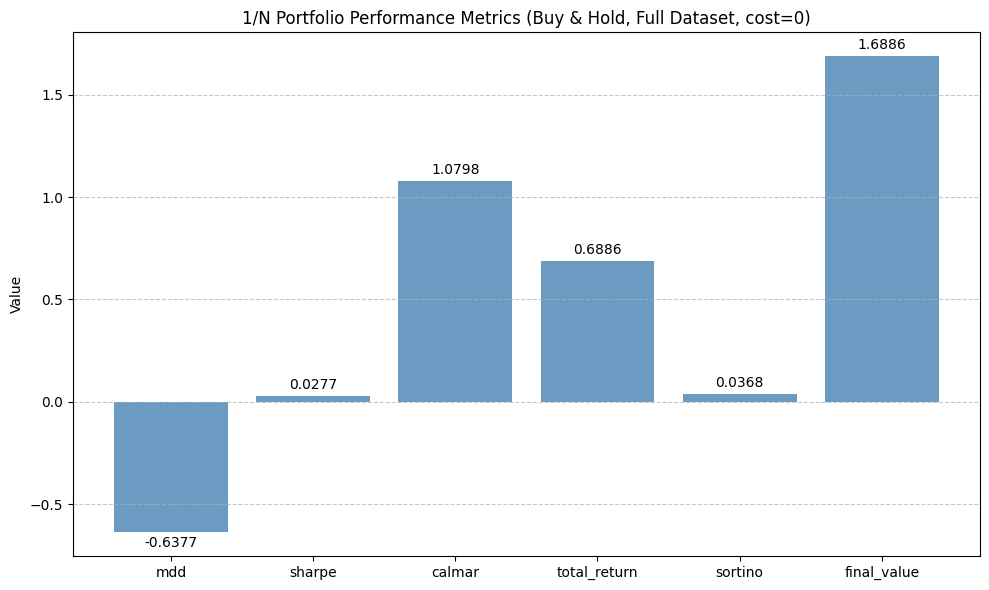

In [9]:
labels = list(metrics_1n_full.keys())
values = list(metrics_1n_full.values())

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, values, color='steelblue', alpha=0.8)
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_title('1/N Portfolio Performance Metrics (Buy & Hold, Full Dataset, cost=0)')
ax.set_ylabel('Value')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


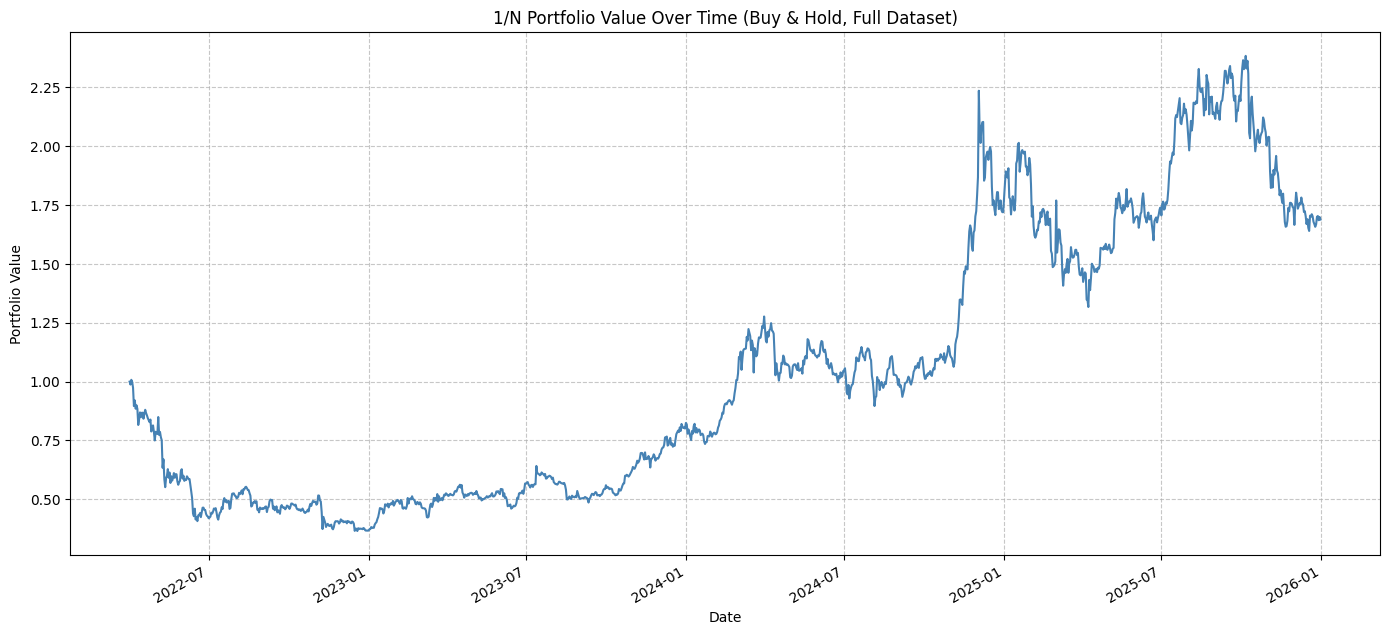

In [10]:
plt.figure(figsize=(14, 7))
fig = plt.gcf()
plt.plot(results_1n_full['date'], results_1n_full['portfolio_values'],
         linewidth=1.5, color='steelblue')
plt.title('1/N Portfolio Value Over Time (Buy & Hold, Full Dataset)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
fig.autofmt_xdate()
plt.show()


### A2. Mean-Variance Portfolio (Weekly Rebalancing)

In [11]:
# MV save path
file_path2 = 'Results/mean variance.npy'
folder_path2 = os.path.dirname(file_path2)
if not os.path.exists(folder_path2):
    os.makedirs(folder_path2, exist_ok=True)


In [12]:
costs = [0, 0.0001, 0.0005, 0.001, 0.0015, 0.0025, 0.005]

result_tables_mv_full = {}
mdd_mv    = []
sharpe_mv = []
calmar_mv = []
total_return_mv = []
sortino_mv = []

for c in costs:
    print(f'running MV (full dataset) | cost: {c} ...')
    res = mv_weight_returns(combined, all_coins, lookback=60, risk_aversion=1.0, cost=c)
    result_tables_mv_full[c] = res

    m = calculate_metrics(res)

    if c == 0.001:
        np.save(file_path2, m)
        print(f'Saved: {file_path2}')
        res.to_csv(os.path.join(
            'Results/',
            'mean_variance_full.csv'), index=False)

    mdd_mv.append(m['mdd'])
    sharpe_mv.append(m['sharpe'])
    calmar_mv.append(m['calmar'])
    total_return_mv.append(m['total_return'])
    sortino_mv.append(m['sortino'])

metrics_mv_full = pd.DataFrame({
    'costs':  costs,
    'mdd':    mdd_mv,
    'sharpe': sharpe_mv,
    'calmar': calmar_mv,
    'total_return': total_return_mv,
    'sortino': sortino_mv
}).set_index('costs')
metrics_mv_full


running MV (full dataset) | cost: 0 ...
running MV (full dataset) | cost: 0.0001 ...
running MV (full dataset) | cost: 0.0005 ...
running MV (full dataset) | cost: 0.001 ...
Saved: /content/drive/MyDrive/klines csv/performance_metrics/mean variance.npy
running MV (full dataset) | cost: 0.0015 ...
running MV (full dataset) | cost: 0.0025 ...
running MV (full dataset) | cost: 0.005 ...


,mdd,sharpe,calmar,total_return,sortino
costs,,,,,
0.0000,-0.687686,0.035895,2.044494,1.405970,0.051010
0.0001,-0.688937,0.035684,2.007308,1.382909,0.050708
0.0005,-0.693892,0.034838,1.863164,1.292834,0.049505
0.0010,-0.699976,0.033780,1.692874,1.184972,0.047996
0.0015,-0.705943,0.032721,1.532900,1.082139,0.046487
0.0025,-0.717529,0.030600,1.241268,0.890645,0.043466
0.0050,-0.744576,0.025288,0.651251,0.484906,0.035909


#### MV: Transaction Cost Sensitivity (Full Dataset)

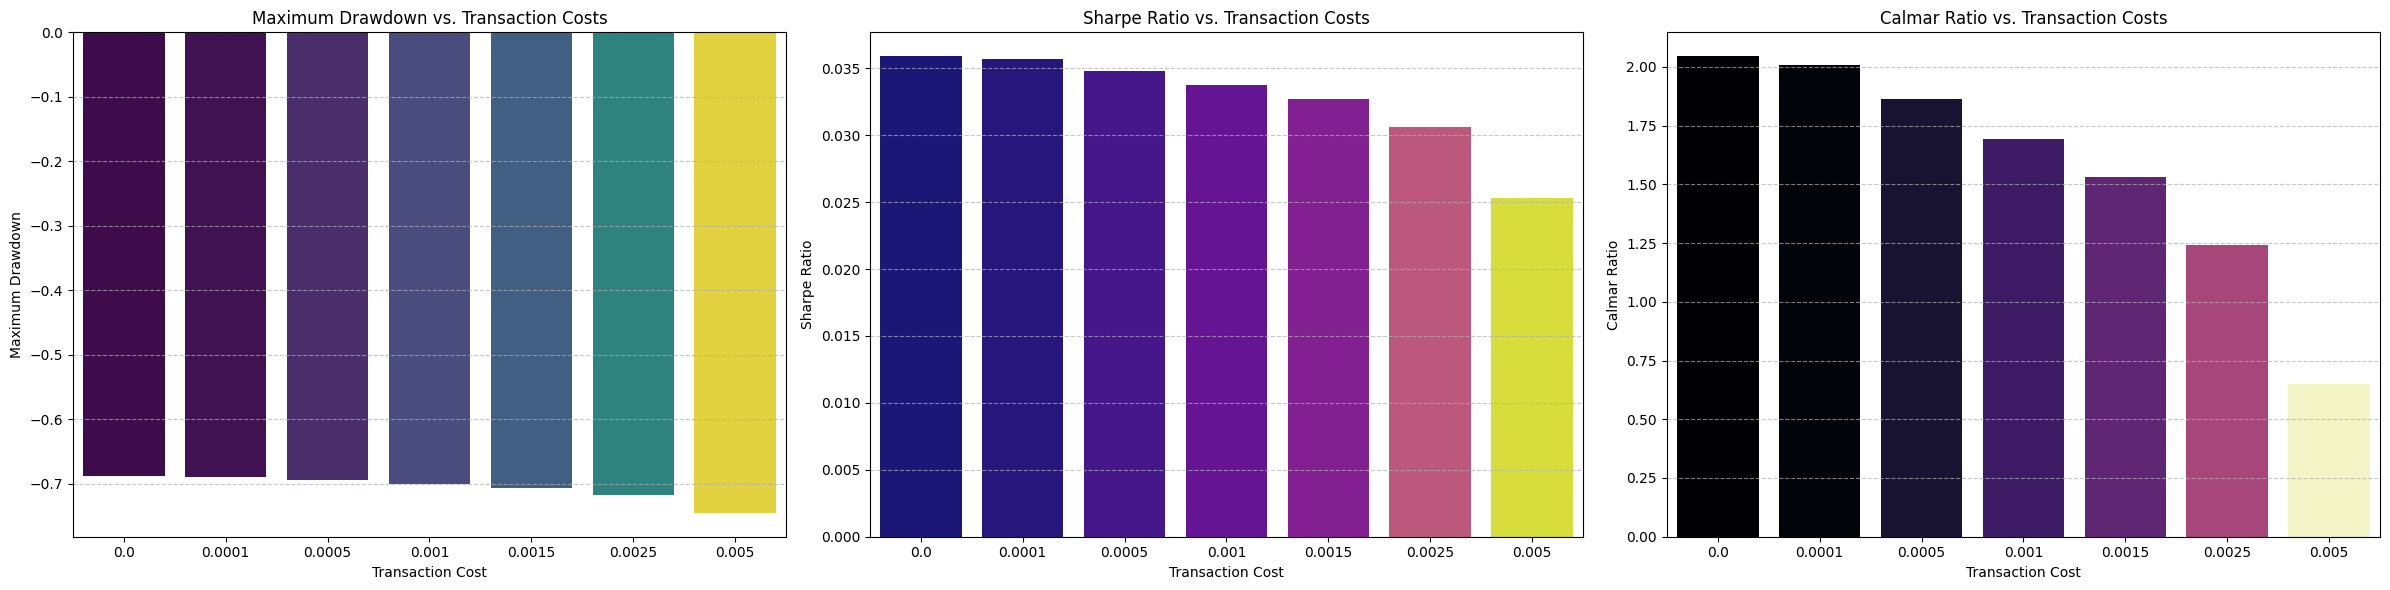

In [13]:
metrics_mv_plot = metrics_mv_full.reset_index()

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

sns.barplot(x='costs', y='mdd',    data=metrics_mv_plot, palette='viridis',
            ax=axes[0], hue='costs', legend=False)
axes[0].set_title('Maximum Drawdown vs. Transaction Costs')
axes[0].set_xlabel('Transaction Cost')
axes[0].set_ylabel('Maximum Drawdown')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

sns.barplot(x='costs', y='sharpe', data=metrics_mv_plot, palette='plasma',
            ax=axes[1], hue='costs', legend=False)
axes[1].set_title('Sharpe Ratio vs. Transaction Costs')
axes[1].set_xlabel('Transaction Cost')
axes[1].set_ylabel('Sharpe Ratio')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

sns.barplot(x='costs', y='calmar', data=metrics_mv_plot, palette='magma',
            ax=axes[2], hue='costs', legend=False)
axes[2].set_title('Calmar Ratio vs. Transaction Costs')
axes[2].set_xlabel('Transaction Cost')
axes[2].set_ylabel('Calmar Ratio')
axes[2].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


### A3. Comparison: 1/N vs MV (Full Dataset)

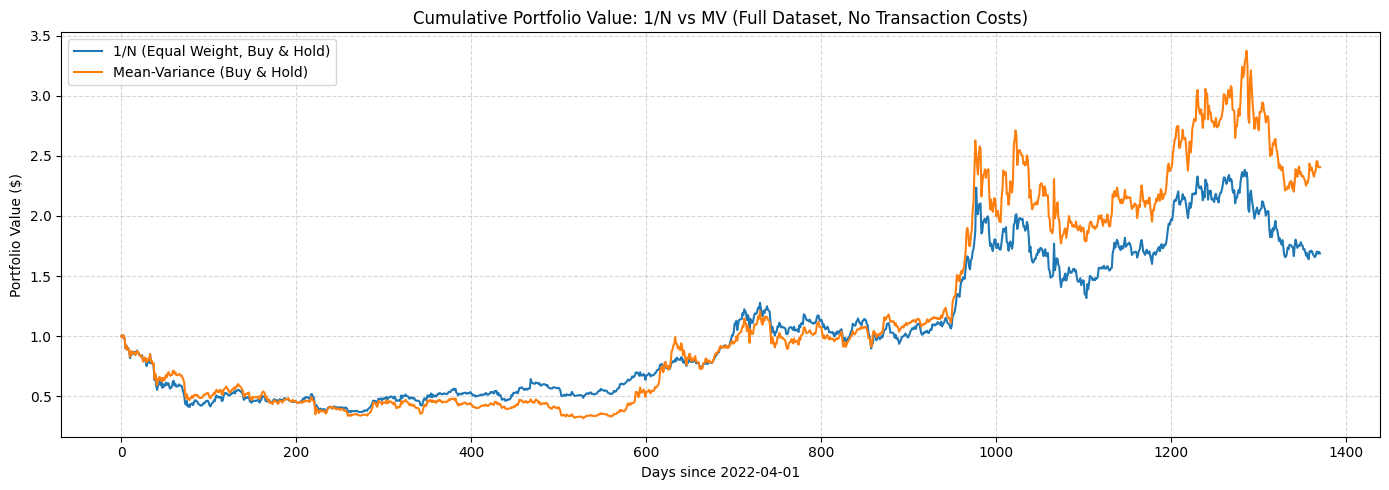


=== Full Dataset Comparison (zero cost) ===
Strategy                                Return        MDD     Sharpe     Calmar    Sortino
----------------------------------------------------------------------------------------------------
1/N (Buy & Hold)                        0.6886    -0.6377     0.0277     1.0798     0.0368
Mean-Variance (Weekly Rebal)            1.4060    -0.6877     0.0359     2.0445     0.0510


In [20]:
eq_res_full = results_1n_full
mv_res_full = result_tables_mv_full[0]

plt.figure(figsize=(14, 5))
plt.plot(eq_res_full['portfolio_values'].values,
         label='1/N (Equal Weight, Buy & Hold)', linewidth=1.5)
plt.plot(mv_res_full['portfolio_values'].values,
         label='Mean-Variance (Buy & Hold)', linewidth=1.5)
plt.title('Cumulative Portfolio Value: 1/N vs MV (Full Dataset, No Transaction Costs)')
plt.xlabel('Days since 2022-04-01')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('\n=== Full Dataset Comparison (zero cost) ===')
print(f"{'Strategy':<35} {'Return':>10} {'MDD':>10} {'Sharpe':>10} {'Calmar':>10} {'Sortino':>10}")
print('-' * 100)
for name, res in [('1/N (Buy & Hold)', eq_res_full),
                  ('Mean-Variance (Buy & Hold)', mv_res_full)]:
    m = calculate_metrics(res)
    print(f'{name:<35} {m["total_return"]:>10.4f} {m["mdd"]:>10.4f} {m["sharpe"]:>10.4f} {m["calmar"]:>10.4f} {m["sortino"]:>10.4f}')


---
## Section B: Test Set Only

Running benchmarks on the test period only (80/20 split, ~Apr 2025 → end).
This matches the evaluation period used by CMVO and the ML models.


### B1. 1/N Portfolio (Buy & Hold, Test Set)

In [15]:
results_1n_test = eq_weight_returns(test_prices, all_coins, cost=0)
metrics_1n_test = calculate_metrics(results_1n_test)

print('=== 1/N Portfolio Metrics (Test Set, Buy & Hold) ===')
for metric, value in metrics_1n_test.items():
    print(f'  {metric:>12}: {value:.4f}')


=== 1/N Portfolio Metrics (Test Set, Buy & Hold) ===
           mdd: -0.3377
        sharpe: 0.0363
        calmar: 0.5491
  total_return: 0.1855
       sortino: 0.0545
   final_value: 1.1855


### B2. Mean-Variance Portfolio (Buy & Hold, Test Set)

In [16]:
results_mv_test = mv_weight_returns(test_prices, all_coins, lookback=60,
                                    risk_aversion=1.0, cost=0)
metrics_mv_test = calculate_metrics(results_mv_test)

print('=== MV Portfolio Metrics (Test Set, cost=0) ===')
for metric, value in metrics_mv_test.items():
    print(f'  {metric:>12}: {value:.4f}')


=== MV Portfolio Metrics (Test Set, cost=0) ===
           mdd: -0.3551
        sharpe: 0.0380
        calmar: 0.5865
  total_return: 0.2082
       sortino: 0.0556
   final_value: 1.2082


### B3. Random Walk Forecast Baseline (Test Set)

The random walk (persistence) forecast predicts that tomorrow's price equals today's price.
This computes the forecast errors on the test set.


In [17]:
# Random walk forecast on test set
df_test = test_prices.copy()
cols_to_forecast = [c for c in df_test.columns if 'USDT' in c]

randomwalk_preds = df_test[cols_to_forecast].shift(1).iloc[1:]
df_test_trimmed  = df_test[cols_to_forecast].iloc[1:]

# Forecast errors
errors = df_test_trimmed.values - randomwalk_preds.values
mae  = np.abs(errors).mean(axis=0)
rmse = np.sqrt((errors ** 2).mean(axis=0))

print("=== Random Walk Forecast Errors (Test Set) ===")
print(f"{'Coin':<20} {'MAE':>12} {'RMSE':>12}")
print("-" * 44)
for j, coin in enumerate(cols_to_forecast):
    print(f"{coin:<20} {mae[j]:>12.4f} {rmse[j]:>12.4f}")

print(f"\n{'AVERAGE':<20} {mae.mean():>12.4f} {rmse.mean():>12.4f}")

print("\nActuals (first 5 rows):")
print(df_test_trimmed.head())
print("\nRandom Walk Predictions (first 5 rows):")
print(randomwalk_preds.head())


=== Random Walk Forecast Errors (Test Set) ===
Coin                          MAE         RMSE
--------------------------------------------
ADAUSDT                    0.0206       0.0286
BCHUSDT                   13.5577      17.9795
BNBUSDT                   16.2715      26.4489
BTCUSDT                 1482.7940    2011.3920
ETHUSDT                   83.3432     122.6047
SOLUSDT                    5.0703       6.8138
TRXUSDT                    0.0037       0.0050
XRPUSDT                    0.0631       0.0906

AVERAGE                  200.1405     273.1704

Actuals (first 5 rows):
            ADAUSDT  BCHUSDT  BNBUSDT   BTCUSDT  ETHUSDT  SOLUSDT  TRXUSDT  XRPUSDT
time                                                                               
2025-04-02   0.6400    293.0   590.68  82516.29  1795.22   117.42   0.2341   2.0237
2025-04-03   0.6508    301.3   592.67  83213.09  1817.23   117.17   0.2382   2.0648
2025-04-04   0.6603    301.4   597.71  83889.87  1816.87   122.79   0.2390  

### B4. Comparison: 1/N vs MV (Test Set)

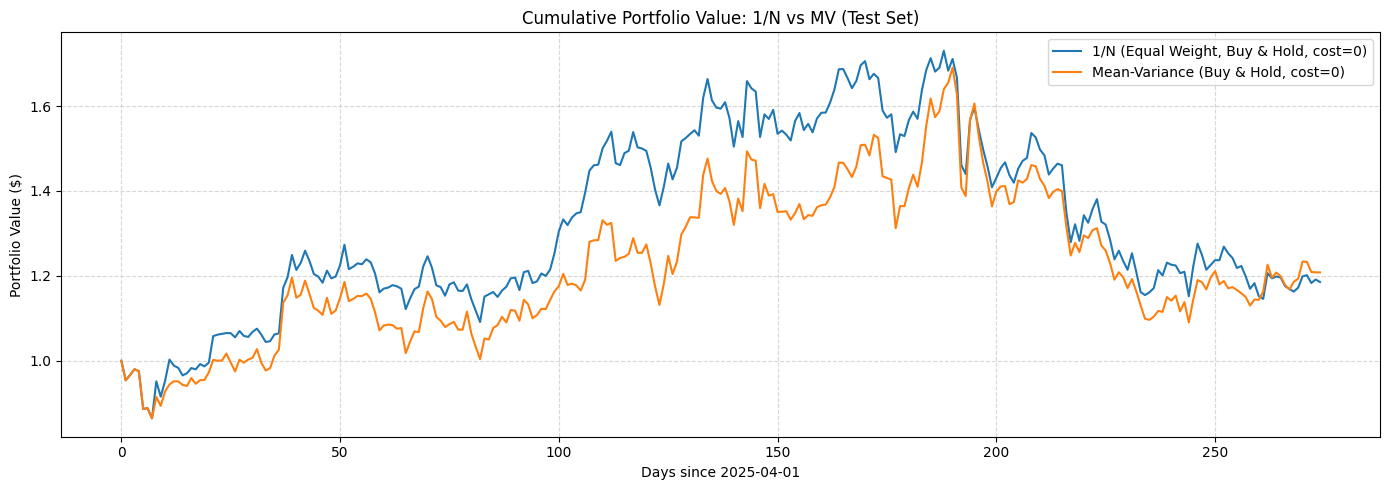


=== Test Set Comparison ===
Strategy                               Final   Return        MDD     Sharpe     Calmar    Sortino
------------------------------------------------------------------------------------------
1/N (Buy & Hold)                      1.1855   0.1855    -0.3377     0.0363     0.5491     0.0545
MV (cost=0)                           1.2082   0.2082    -0.3551     0.0380     0.5865     0.0556


In [18]:
plt.figure(figsize=(14, 5))
plt.plot(results_1n_test['portfolio_values'].values,
         label='1/N (Equal Weight, Buy & Hold, cost=0)', linewidth=1.5)
plt.plot(results_mv_test['portfolio_values'].values,
         label='Mean-Variance (Buy & Hold, cost=0)', linewidth=1.5)
plt.title('Cumulative Portfolio Value: 1/N vs MV (Test Set)')
plt.xlabel(f'Days since {test_prices.index[0].date()}')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('\n=== Test Set Comparison ===')
print(f"{'Strategy':<35} {'Final':>8} {'Return':>8} {'MDD':>10} {'Sharpe':>10} {'Calmar':>10} {'Sortino':>10}")
print('-' * 90)
for name, res in [('1/N (Buy & Hold)', results_1n_test),
                  ('MV (cost=0)', results_mv_test)]:
    m = calculate_metrics(res)
    print(f'{name:<35} {m["final_value"]:>8.4f} {m["total_return"]:>8.4f} {m["mdd"]:>10.4f} {m["sharpe"]:>10.4f} {m["calmar"]:>10.4f} {m["sortino"]:>10.4f}')
